# 13. 계약조건 증분의 식별 — 쌍둥이 · 이질성 · DiD

12번은 시장상태·발행사·분기를 제거한 **부분증분**까지 갔고, 그건 여전히 *조건부 연관*이었다.
여기서는 식별을 세 층으로 끌어올린다.

| 절 | 설계 | 얻는 것 | 얻지 못하는 것 |
|---|---|---|---|
| **13-1** | 쌍둥이 within-cell (발행사×발행일×바스켓×만기×관측수 고정효과) | 시장상태가 **정의상 동일**한 비교. 반사실이 데이터에 실제로 존재 | 조건을 동시 선택하는 내생성은 남음 |
| **13-2** | within-cell 잔차 위 이질성 포레스트 (R-learner) | 증분이 **어디서** 달라지는지 분할점을 데이터가 찾음 | 인과 아님 — 함수형만 풀고 식별은 그대로 |
| **13-3** | 2024 홍콩지수 ELS 사태 DiD / 사건연구 / 삼중차분 | 외생 시점충격에 대한 **인과 추정** | 계약조건 자체의 인과는 아님(축이 다름) |

**causal forest 를 인과로 부르지 않는 이유를 먼저 적는다.** 발행사는 배리어·행사가·쿠폰을 동시에
정하므로 조건부 무교란이 성립하지 않고, 무엇보다 **중첩(overlap)이 깨진다** — level 상관이
`b_over_k`↔`B` 0.98, `B`↔`K` −0.78 이라 (K·쿠폰·변동성)이 주어지면 배리어가 거의 결정된다.
causal forest 가 완화하는 것은 **함수형 가정**이지 **식별 가정**이 아니다. 그래서 13-2 는
"연관의 이질성 탐색"으로만 쓴다.

대상은 12번과 같이 **DART 공시 공정가** `fair = FAIR_VALUE / ISU_PRC_DETAIL` 이고, 증분은 발행가
10,000원 기준 원 단위다. 파생 조건(`cpn_spread`=coupon−r, `b_over_k`=B/K, `stepdown`=Kfirst−K)은
원 조건의 함수이므로 제외하고 **독립 조건 `B`·`K`·`Kfirst`·`coupon`·`nobs`** 만 다룬다.


In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import lstsq, inv, pinv
from util import file_manager as fm, plot as _plot

FACE = 10000
df = pd.read_parquet(fm.source())
df["date"] = df.isu_ord.map(lambda o: pd.Timestamp.fromordinal(int(o)))
df["year"] = df.date.dt.year
df["ym"] = df.date.dt.to_period("M")
df["struct"] = df.opt_type.astype(str) + " x " + np.where(df.ki_yn.astype(int) == 1, "KI", "no-KI")
df["is_lizard"] = (df.opt_type.astype(str) == "LIZARD").astype(int)
# 홍콩지수(HSCEI/HSI) 편입 — 13-3 DiD 처리군
_udl = df[["udl1", "udl2", "udl3"]].astype(str)
df["hk"] = _udl.apply(lambda r: any(str(x).replace("^", "") in ("HSCE", "HSI") for x in r), axis=1)

UNIT = {"B": (0.05, "barrier +5%p"), "K": (0.05, "final strike +5%p"),
        "Kfirst": (0.05, "first strike +5%p"), "coupon": (0.01, "coupon +1%p"),
        "nobs": (1.0, "+1 observation")}
PRIMARY = list(UNIT)
CELLS = {"A: issuer x date x basket x tenor x nobs": ["issuer", "isu_ord", "udl_key", "tenor", "nobs"],
         "B: issuer x date x basket": ["issuer", "isu_ord", "udl_key"],
         "C: date x basket": ["isu_ord", "udl_key"]}
print(f"공시 계약 {len(df):,}건 | {df.date.min().date()} ~ {df.date.max().date()}")
print(f"홍콩지수 편입 {int(df.hk.sum()):,}건 ({df.hk.mean()*100:.1f}%)")

공시 계약 58,790건 | 2015-01-05 ~ 2026-05-12
홍콩지수 편입 33,583건 (57.1%)


In [2]:
# ---- within-cell 고정효과 증분 추정기 ---------------------------------------
def _demean(M, key):
    """셀 내 평균제거 (고정효과 흡수)."""
    return M - pd.DataFrame(M).groupby(key).transform("mean").values


def _cluster_vc(X, e, cluster):
    """클러스터 강건 분산-공분산. 같은 날 발행분은 시장충격을 공유한다."""
    XtX_inv = pinv(X.T @ X)
    S = np.zeros((X.shape[1], X.shape[1]))
    for _, idx in pd.DataFrame({"c": np.asarray(cluster)}).groupby("c").indices.items():
        s = X[idx].T @ e[idx]
        S += np.outer(s, s)
    G = len(np.unique(cluster))
    return XtX_inv @ S @ XtX_inv * (G / max(G - 1, 1))


def within_slopes(d, terms, keys, multivariate=True, min_cell=2):
    """셀 고정효과를 흡수한 뒤 terms 의 증분(원/단위) + 클러스터 SE.
     multivariate=True 면 terms 를 동시에 넣어 '다른 조건도 고정' 한 증분."""
    use = [t for t in terms if t not in keys]          # 셀 키에 든 변수는 셀 내 변동이 없다
    g = d.dropna(subset=use + ["fair"]).copy()
    key = g[keys].astype(str).agg("|".join, axis=1).values
    cnt = pd.Series(key).value_counts()
    keep = pd.Series(key).map(cnt).values >= min_cell
    g = g[keep]; key = key[keep]
    if len(g) < 200:
        return pd.DataFrame(), {}
    Y = _demean(g[["fair"]].astype(float).values, key).ravel()
    X = _demean(g[use].astype(float).values, key)
    meta = {"n": len(g), "n_cell": len(np.unique(key)), "n_cluster": g.isu_ord.nunique()}
    rows = []
    if multivariate:
        b, *_ = lstsq(X, Y, rcond=None)
        e = Y - X @ b
        V = _cluster_vc(X, e, g.isu_ord.values)
        C = np.corrcoef(X, rowvar=False)
        vif = np.diag(inv(C)) if X.shape[1] > 1 else np.ones(1)
        for j, t in enumerate(use):
            u = UNIT[t][0]
            rows.append({"term": t, "kind": "within-multi", "slope": b[j]*u*FACE,
                         "se": np.sqrt(V[j, j])*u*FACE, "vif": float(vif[j]), **meta})
    else:
        for j, t in enumerate(use):
            x = X[:, [j]]
            b, *_ = lstsq(x, Y, rcond=None)
            e = Y - x @ b
            V = _cluster_vc(x, e, g.isu_ord.values)
            u = UNIT[t][0]
            rows.append({"term": t, "kind": "within-uni", "slope": float(b[0])*u*FACE,
                         "se": float(np.sqrt(V[0, 0]))*u*FACE, "vif": np.nan, **meta})
    return pd.DataFrame(rows), meta


print("추정기 준비 완료. 셀 정의:", list(CELLS))

추정기 준비 완료. 셀 정의: ['A: issuer x date x basket x tenor x nobs', 'B: issuer x date x basket', 'C: date x basket']


## 13-1. 쌍둥이 within-cell 증분

**같은 발행사가 같은 날 같은 기초자산 바스켓으로 낸 상품끼리** 비교한다. 이 셀 안에서는 변동성·상관·금리·
발행사 마진정책이 **정의상 동일**하므로, 12번의 FWL 부분증분이 근사로 제거하려 했던 교란이 설계로 사라진다.

셀 정의를 세 가지로 두어 민감도를 본다(A가 가장 엄격). `nobs`·`tenor` 는 A 셀의 키에 들어 있어
그 안에서는 추정할 수 없으므로 더 느슨한 셀에서만 나온다.

`within-uni` 는 조건 하나씩, `within-multi` 는 5개를 동시에 넣어 **다른 계약조건까지 고정**한 증분이다.
셀 내부에서는 공선성이 낮아져(VIF 최대 2.8) 다변량이 가능해진다 — level 에서는 불가능했던 것이다.


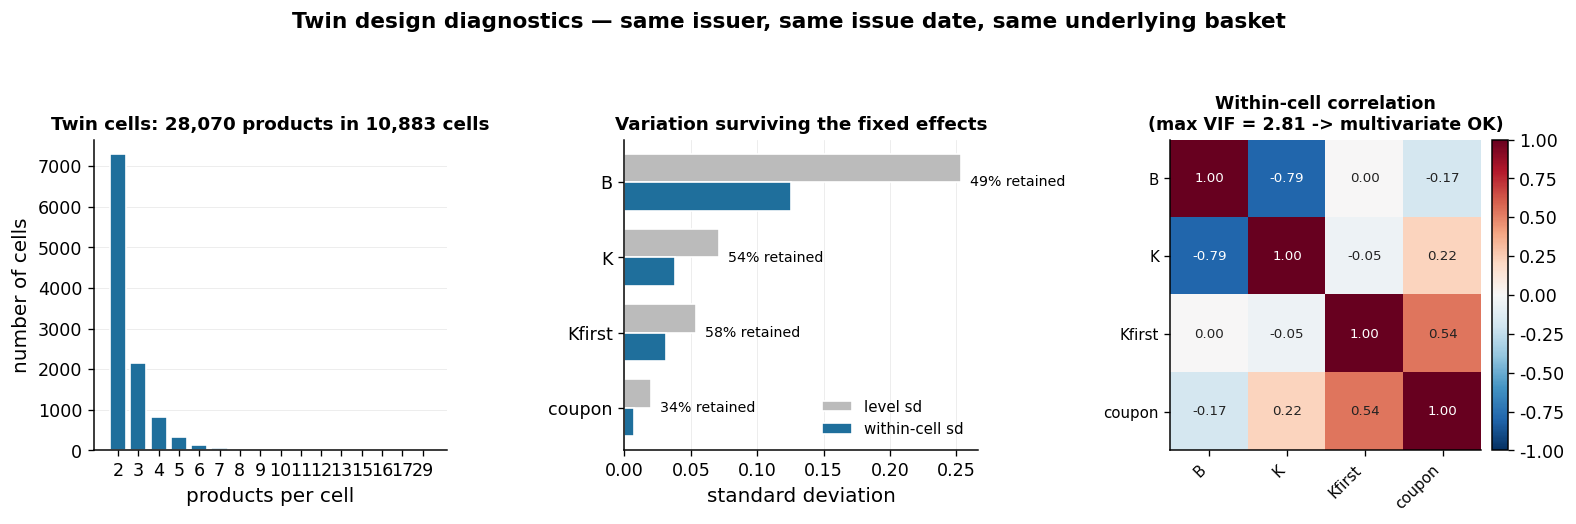

         within    level  retained
B       0.12537  0.25341   0.49472
K       0.03830  0.07088   0.54036
Kfirst  0.03150  0.05412   0.58192
coupon  0.00684  0.02005   0.34143
saved -> ci_twin_diagnostics.png


In [3]:
# 쌍둥이 표본 진단: 셀 크기 · 셀 내 잔존변동 · 공선성
KEY_A = CELLS["A: issuer x date x basket x tenor x nobs"]
g = df.dropna(subset=["B", "K", "Kfirst", "coupon", "fair"])
key = g[KEY_A].astype(str).agg("|".join, axis=1)
cnt = key.map(key.value_counts())
tw = g[cnt >= 2]; twkey = key[cnt >= 2].values

P4 = ["B", "K", "Kfirst", "coupon"]
Wd = pd.DataFrame(_demean(tw[P4].astype(float).values, twkey), columns=P4)

fig, ax = plt.subplots(1, 3, figsize=(_plot.SLIDE_W, 4.4))
cs = key[cnt >= 2].value_counts().value_counts().sort_index()
ax[0].bar(cs.index.astype(str), cs.values, color=_plot._QUAL[0], edgecolor="white")
ax[0].set_xlabel("products per cell"); ax[0].set_ylabel("number of cells")
ax[0].set_title(f"Twin cells: {twkey.__len__():,} products in {len(np.unique(twkey)):,} cells", fontsize=11)
ax[0].grid(axis="y", color="#dddddd", lw=.5, alpha=.6)

r = pd.DataFrame({"within": Wd.std(), "level": tw[P4].astype(float).std()})
r["retained"] = r.within / r.level
y = np.arange(len(P4)); w = .38
ax[1].barh(y - w/2, r.level, w, label="level sd", color="#bbbbbb", edgecolor="white")
ax[1].barh(y + w/2, r.within, w, label="within-cell sd", color=_plot._QUAL[0], edgecolor="white")
for i, v in enumerate(r.retained):
    ax[1].text(r.level.iloc[i], i, f"  {v*100:.0f}% retained", va="center", fontsize=8.5)
ax[1].set_yticks(y); ax[1].set_yticklabels(P4); ax[1].invert_yaxis()
ax[1].set_xlabel("standard deviation"); ax[1].legend(fontsize=9)
ax[1].set_title("Variation surviving the fixed effects", fontsize=11)
ax[1].grid(axis="x", color="#dddddd", lw=.5, alpha=.6)

C = Wd.corr()
im = ax[2].imshow(C.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax[2].set_xticks(range(4)); ax[2].set_xticklabels(P4, rotation=45, ha="right", fontsize=9)
ax[2].set_yticks(range(4)); ax[2].set_yticklabels(P4, fontsize=9)
for i in range(4):
    for j in range(4):
        ax[2].text(j, i, f"{C.values[i,j]:.2f}", ha="center", va="center", fontsize=8,
                   color="white" if abs(C.values[i, j]) > .6 else "#222")
vif = np.diag(inv(C.values))
ax[2].set_title("Within-cell correlation\n(max VIF = %.2f -> multivariate OK)" % vif.max(), fontsize=10.5)
fig.colorbar(im, ax=ax[2], fraction=.046, pad=.03)

fig.suptitle("Twin design diagnostics — same issuer, same issue date, same underlying basket",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.91))
fig.savefig(fm.image("ci_twin_diagnostics")); plt.show()
print(r.round(5).to_string())
print("saved ->", fm.image("ci_twin_diagnostics").name)

=== 증분 (원/단위) — 설계별 ===
cell   12: FWL partial A: issuer x date x basket x tenor x nobs            B: issuer x date x basket            C: date x basket           
kind    partial (nb12)                             within-multi within-uni              within-multi within-uni     within-multi within-uni
term                                                                                                                                       
B               -156.2                                    -24.1      -14.4                     -22.2      -11.5            -28.1      -10.8
K                 -7.4                                    -25.4       23.9                     -32.6       12.2            -60.4       -1.6
Kfirst          -106.2                                    -53.1      -96.9                     -58.5      -90.9            -94.2     -109.3
coupon           -68.8                                    -76.7      -93.9                     -70.4      -88.5            -47.9      -7

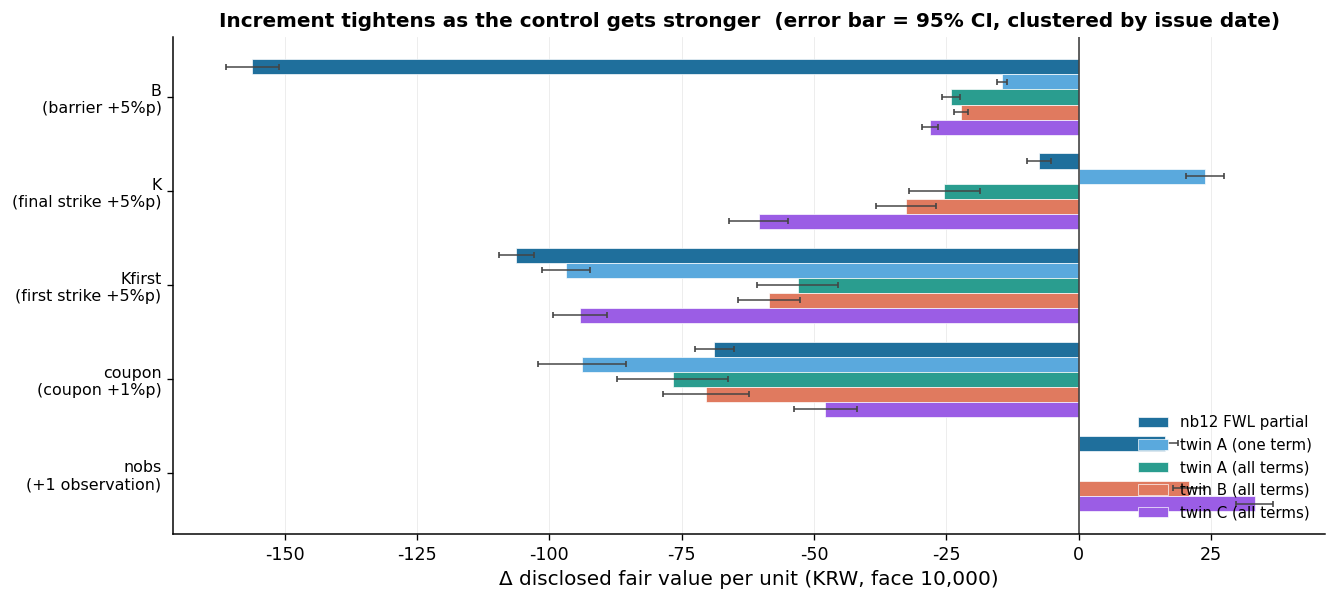

saved -> ci_within_slopes.png | ci_within_slopes.csv


In [4]:
# 셀 정의 x (uni/multi) 증분
rows = []
for cname, keys in CELLS.items():
    for multi in (False, True):
        s, meta = within_slopes(df, PRIMARY, keys, multivariate=multi)
        if len(s):
            s["cell"] = cname
            rows.append(s)
WS = pd.concat(rows, ignore_index=True)
WS.to_csv(fm.stat("ci_within_slopes"), index=False)

# 12번 FWL 부분증분과 나란히
try:
    OLD = pd.read_csv(fm.stat("ct_slope_overall"))
    OLD = OLD[(OLD.kind == "partial") & (OLD.term.isin(PRIMARY))][["term", "slope", "se"]]
    OLD["cell"] = "12: FWL partial"; OLD["kind"] = "partial (nb12)"
except FileNotFoundError:
    OLD = pd.DataFrame()
CMP = pd.concat([OLD, WS[["term", "slope", "se", "cell", "kind"]]], ignore_index=True)

print("=== 증분 (원/단위) — 설계별 ===")
pv = CMP.pivot_table(index="term", columns=["cell", "kind"], values="slope").reindex(PRIMARY)
print(pv.round(1).to_string())
print("\n=== 가장 엄격한 설계 (A, 다변량) ===")
a = WS[(WS.cell.str.startswith("A")) & (WS.kind == "within-multi")].set_index("term")
print(pd.DataFrame({"unit": [UNIT[t][1] for t in a.index],
                    "slope": a.slope.round(1).astype(str) + " ±" + (1.96*a.se).round(1).astype(str),
                    "VIF": a.vif.round(2), "n": a.n, "cells": a.n_cell}).to_string())

fig, a2 = plt.subplots(figsize=(_plot.SLIDE_W*.85, 5.2))
order = [("12: FWL partial", "partial (nb12)"),
         ("A: issuer x date x basket x tenor x nobs", "within-uni"),
         ("A: issuer x date x basket x tenor x nobs", "within-multi"),
         ("B: issuer x date x basket", "within-multi"),
         ("C: date x basket", "within-multi")]
LAB = ["nb12 FWL partial", "twin A (one term)", "twin A (all terms)", "twin B (all terms)", "twin C (all terms)"]
y = np.arange(len(PRIMARY)); w = .16
for j, ((c, k), lb) in enumerate(zip(order, LAB)):
    s = CMP[(CMP.cell == c) & (CMP.kind == k)].set_index("term").reindex(PRIMARY)
    a2.barh(y + (j - 2)*w, s.slope.values, w, xerr=1.96*s.se.values, label=lb,
            color=_plot._QUAL[j % len(_plot._QUAL)], edgecolor="white", linewidth=.4,
            error_kw=dict(ecolor="#444", lw=.9, capsize=2))
a2.set_yticks(y); a2.set_yticklabels([f"{t}\n({UNIT[t][1]})" for t in PRIMARY], fontsize=9.5)
a2.invert_yaxis(); a2.axvline(0, color="#444", lw=1.0)
a2.set_xlabel("Δ disclosed fair value per unit (KRW, face 10,000)")
a2.set_title("Increment tightens as the control gets stronger  (error bar = 95% CI, clustered by issue date)",
             fontsize=12)
a2.legend(fontsize=9, loc="lower right"); a2.grid(axis="x", color="#dddddd", lw=.5, alpha=.6)
fig.tight_layout(); fig.savefig(fm.image("ci_within_slopes")); plt.show()
print("saved ->", fm.image("ci_within_slopes").name, "|", fm.stat("ci_within_slopes").name)

## 13-2. 증분의 이질성 — within-cell 잔차 위 R-learner

12번에서는 제가 기준(연도·3분위)을 **미리 정해** 증분을 쪼갰다. 여기서는 분할점을 **데이터가 고른다**.

셀 고정효과로 이미 교란이 흡수됐으므로 R-learner 의 nuisance 단계(`E[Y|X]`·`E[W|X]`)가 사실상
불필요하다 — 셀 내 평균제거가 그 역할을 한다. 남는 절차는 이렇다.

1. 셀 내 잔차 `ỹ`, `w̃` 를 만든다
2. 목표 조건 `t` 의 잔차를 **다른 조건들의 잔차에 대해 다시 잔차화**한다 (`w̃⊥`) — 셀 안에서 동시에 변하는
   공동처리를 분리 (FWL)
3. pseudo-outcome `ỹ⊥ / w̃⊥` 에 가중 `w̃⊥²` 로 포레스트를 적합 → `τ(x)`

`|w̃⊥|` 이 작은 표본은 pseudo-outcome 이 발산하므로 하위 25% 를 잘라낸다(trimming). `x` 는 **셀 수준**
공변량(변동성·상관·금리·연도·구조 등)이다.

> 다시 강조: 이건 **인과 추정이 아니다.** 조건들이 동시 선택되므로 `τ(x)` 는 "그 공변량 구간에서 관측되는
> 연관의 크기"다. 값이 아니라 **어디서 달라지는가**를 읽는 도구로 쓴다.


In [5]:
from sklearn.ensemble import RandomForestRegressor

HET = ["sig_eff", "rho", "r", "curve_level", "recent_mktvol", "year", "tenor", "nobs",
       "ki_yn", "is_lizard", "K", "Kfirst", "coupon", "B"]


def cate(d, target, keys, trim=.25, n_est=300, seed=0):
    """within-cell 잔차 위 R-learner CATE. 반환 (tau, Z, importance, 진단)."""
    use = [t for t in PRIMARY if t not in keys]
    g = d.dropna(subset=use + ["fair"] + HET).copy()
    key = g[keys].astype(str).agg("|".join, axis=1).values
    cnt = pd.Series(key).value_counts()
    m = pd.Series(key).map(cnt).values >= 2
    g = g[m]; key = key[m]
    Y = _demean(g[["fair"]].astype(float).values, key).ravel()
    X = _demean(g[use].astype(float).values, key)
    ti = use.index(target)
    oth = np.delete(X, ti, axis=1)
    by, *_ = lstsq(oth, Y, rcond=None); ry = Y - oth @ by            # 공동처리 분리
    bt, *_ = lstsq(oth, X[:, ti], rcond=None); rt = X[:, ti] - oth @ bt
    cut = np.quantile(np.abs(rt), trim)
    keep = np.abs(rt) > max(cut, 1e-8)
    het = [h for h in HET if h != target]      # 대상 조건은 이질성 공변량에서 제외
    Z = g[het].astype(float).values
    pseudo = ry[keep] / rt[keep]
    wgt = rt[keep] ** 2
    f = RandomForestRegressor(n_estimators=n_est, min_samples_leaf=80, max_features=.5,
                              random_state=seed, n_jobs=-1)
    f.fit(Z[keep], pseudo, sample_weight=wgt)
    tau = f.predict(Z) * UNIT[target][0] * FACE
    imp = pd.Series(f.feature_importances_, index=het).sort_values(ascending=False)
    return tau, g, imp, {"n": len(g), "kept": int(keep.sum()), "trim": trim,
                         "avg": float(np.average(pseudo, weights=wgt) * UNIT[target][0] * FACE)}


TARGETS = ["B", "coupon", "Kfirst"]
CT = {}
for t in TARGETS:
    d = df[df.ki_yn.astype(int) == 1] if t == "B" else df
    CT[t] = cate(d, t, KEY_A)
    tau, g_, imp, dg = CT[t]
    print(f"[{t}] n={dg['n']:,} kept={dg['kept']:,} (trim {dg['trim']:.0%})  "
          f"가중평균 증분={dg['avg']:+.1f}원  tau 범위 {tau.min():+.0f}~{tau.max():+.0f}  "
          f"IQR {np.percentile(tau,25):+.0f}~{np.percentile(tau,75):+.0f}")
    print(f"     이질성 상위: {', '.join(f'{k}({v:.2f})' for k, v in imp.head(4).items())}")

[B] n=9,951 kept=7,461 (trim 25%)  가중평균 증분=-146.7원  tau 범위 -264~-18  IQR -181~-120
     이질성 상위: year(0.22), sig_eff(0.12), recent_mktvol(0.11), Kfirst(0.10)


[coupon] n=28,070 kept=21,052 (trim 25%)  가중평균 증분=-76.6원  tau 범위 -242~+79  IQR -114~-50
     이질성 상위: sig_eff(0.15), tenor(0.11), rho(0.11), year(0.10)


[Kfirst] n=28,070 kept=21,052 (trim 25%)  가중평균 증분=-53.2원  tau 범위 -207~+143  IQR -92~-3
     이질성 상위: year(0.22), coupon(0.11), sig_eff(0.10), r(0.09)


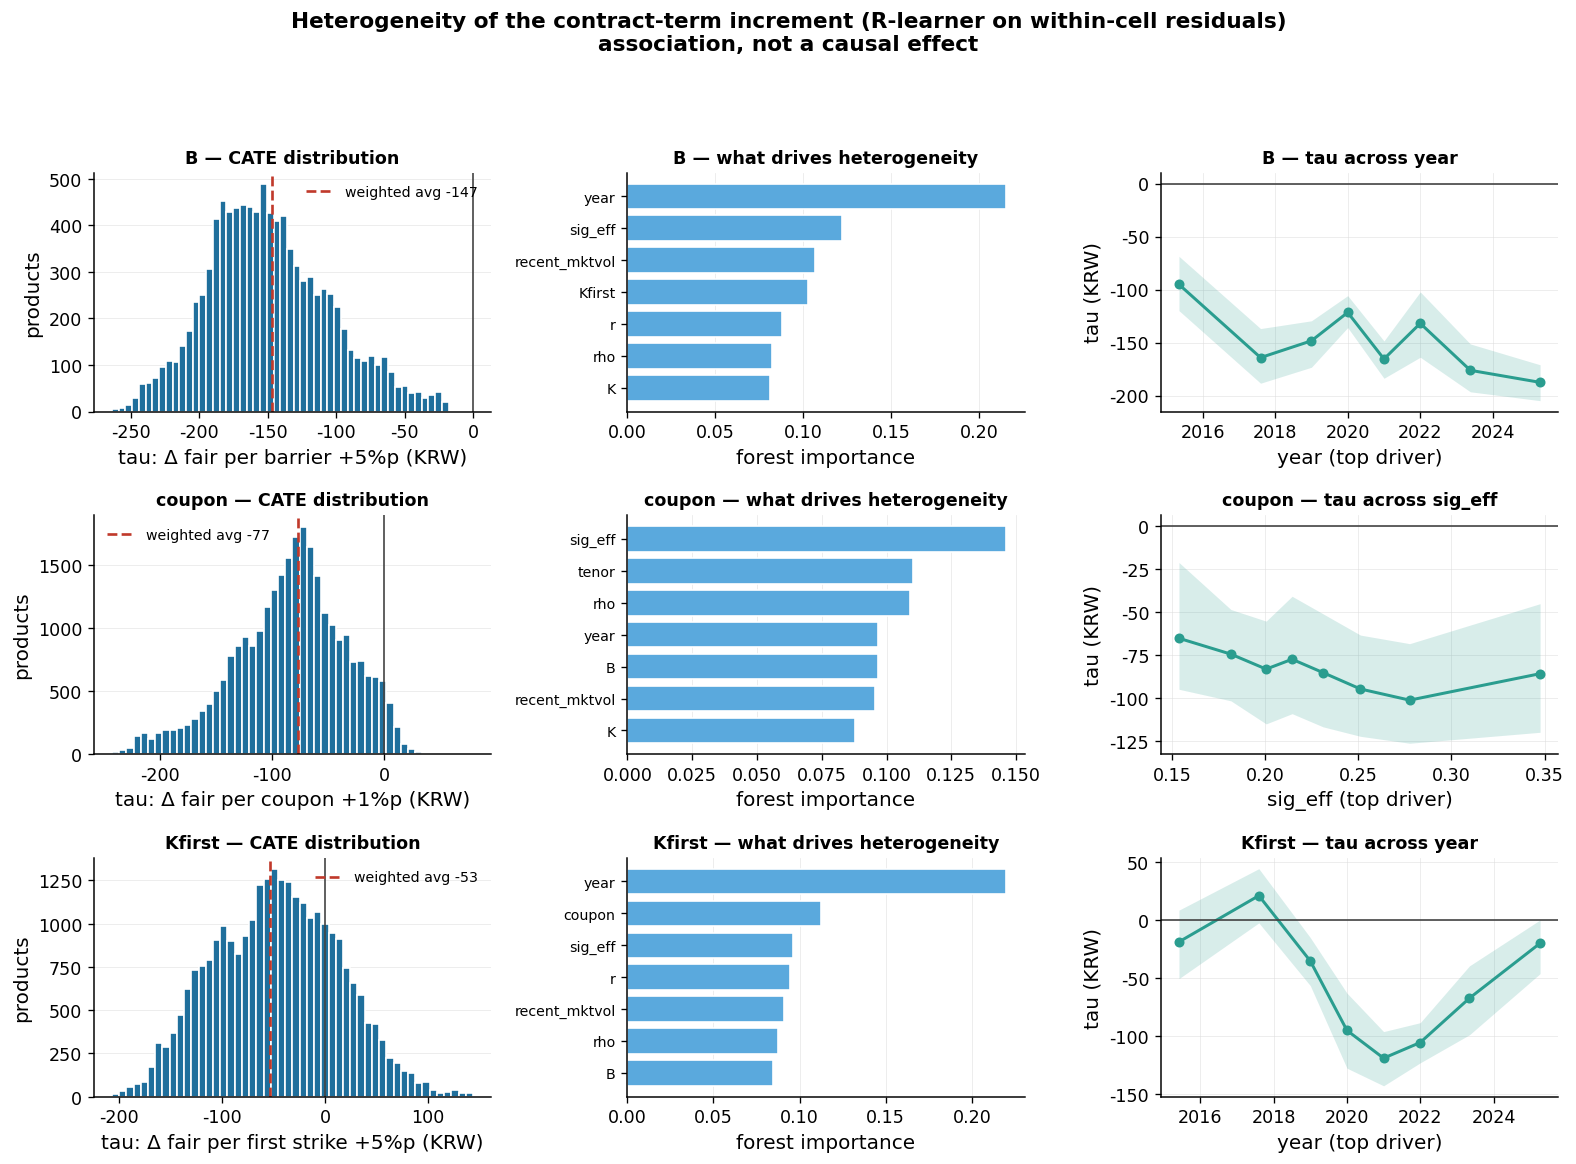

saved -> ci_cate.png | ci_cate_importance.csv


In [6]:
# 그림: tau 분포 + 이질성 중요도 + 주요 공변량별 tau
fig, axs = plt.subplots(len(TARGETS), 3, figsize=(_plot.SLIDE_W, 3.3*len(TARGETS)))
for i, t in enumerate(TARGETS):
    tau, g_, imp, dg = CT[t]
    a = axs[i]
    a[0].hist(tau, bins=50, color=_plot._QUAL[0], edgecolor="white")
    a[0].axvline(dg["avg"], color="#c0392b", lw=1.6, ls="--",
                 label=f"weighted avg {dg['avg']:+.0f}")
    a[0].axvline(0, color="#444", lw=1.0)
    a[0].set_xlabel(f"tau: Δ fair per {UNIT[t][1]} (KRW)"); a[0].set_ylabel("products")
    a[0].set_title(f"{t} — CATE distribution", fontsize=10.5); a[0].legend(fontsize=8.5)
    a[0].grid(axis="y", color="#dddddd", lw=.5, alpha=.6)

    top = imp.head(7)[::-1]
    a[1].barh(range(len(top)), top.values, color=_plot._QUAL[1], edgecolor="white")
    a[1].set_yticks(range(len(top))); a[1].set_yticklabels(top.index, fontsize=8.5)
    a[1].set_xlabel("forest importance")
    a[1].set_title(f"{t} — what drives heterogeneity", fontsize=10.5)
    a[1].grid(axis="x", color="#dddddd", lw=.5, alpha=.6)

    drv = imp.index[0]
    q = pd.qcut(g_[drv].astype(float), 8, duplicates="drop")
    s = pd.DataFrame({"tau": tau, "q": q}).groupby("q", observed=True)["tau"]
    cx = g_.groupby(q, observed=True)[drv].mean().values
    a[2].plot(cx, s.mean().values, "o-", ms=5, lw=1.8, color=_plot._QUAL[2])
    a[2].fill_between(cx, s.quantile(.25).values, s.quantile(.75).values,
                      color=_plot._QUAL[2], alpha=.18, linewidth=0)
    a[2].axhline(0, color="#444", lw=1.0)
    a[2].set_xlabel(f"{drv} (top driver)"); a[2].set_ylabel("tau (KRW)")
    a[2].set_title(f"{t} — tau across {drv}", fontsize=10.5)
    a[2].grid(color="#dddddd", lw=.5, alpha=.6)
fig.suptitle("Heterogeneity of the contract-term increment (R-learner on within-cell residuals)"
             "\nassociation, not a causal effect", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(fm.image("ci_cate")); plt.show()
pd.concat({t: CT[t][2] for t in TARGETS}, axis=1).to_csv(fm.stat("ci_cate_importance"))
print("saved ->", fm.image("ci_cate").name, "|", fm.stat("ci_cate_importance").name)

## 13-3. DiD — 2024 홍콩지수 ELS 사태

여기만 **외생 시점충격**이라 인과 해석이 가능하다. 2024년 초 홍콩 H지수(HSCEI) 급락으로 대규모 손실이
확정되고 감독당국 조치·판매 중단이 이어졌다. 그 충격은 **개별 발행사가 고른 계약조건과 무관**하다.

- **처리군** = 바스켓에 HSCEI 또는 HSI 를 포함한 상품
- **사건 시점** = 2024-01
- **결과** = 공시 공정가(원)
- 발행사·발행월 고정효과 + 발행일 클러스터

먼저 **사건연구**로 평행추세를 확인한다(사전 계수가 0 근처여야 한다). 그 다음 2×2 DiD, 마지막으로
**삼중차분**으로 "사태 이후 배리어 증분이 달라졌는가" 를 본다.

**평행추세는 가정이 아니라 검정 대상이다.** 사전기 상호작용이 모두 0 이라는 결합 F 검정을 먼저
돌리고, 기각되면 그 아래 DiD 계수는 인과로 읽지 않는다.

> **주의: 구성 변화가 또 다른 위협이다.** 사태 이후 홍콩 편입 발행이 2023-12월 96건 → 2024-03월 28건으로
> 급감했다. 살아남은 홍콩 상품이 더 안전한 쪽으로 선택되었다면 DiD 계수는 처리효과가 아니라 구성효과다.
> 계약조건을 통제한 사양을 함께 제시해 그 크기를 가늠한다.


DiD 표본 13,075건  (2022-07 ~ 2025-07)
               n  fair_KRW
treat post                
0     0     5239    9240.3
      1     3758    9638.4
1     0     2653    8913.6
      1     1425    9445.9

단순 2x2 DiD = +134.2원


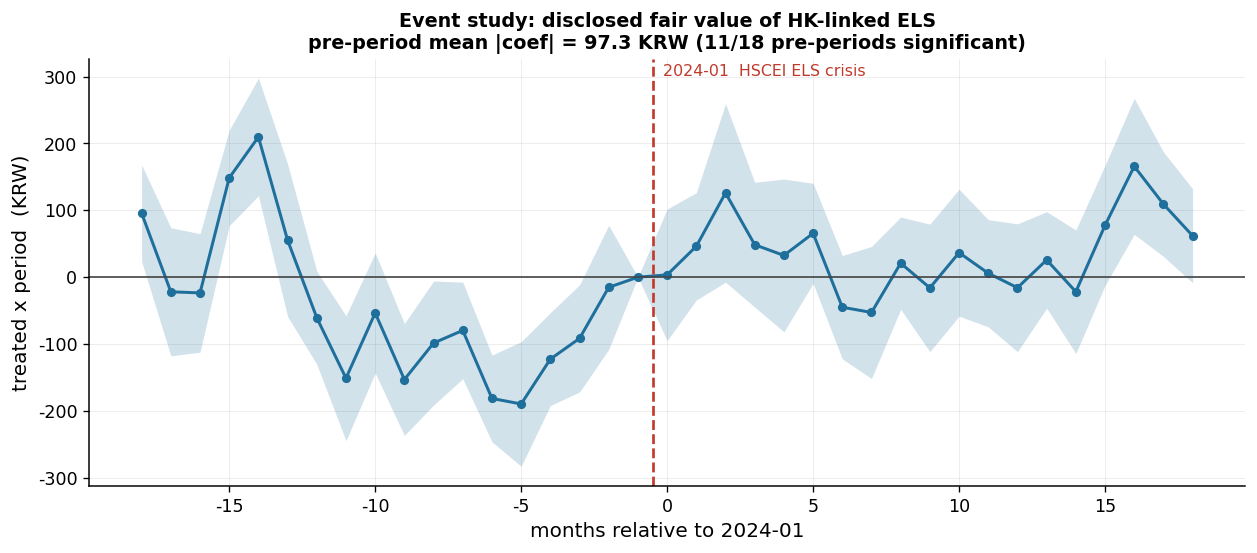

=== 평행추세 검정 ===
  사전기 17개 결합 F = 11.93   p = 4.721e-29
  사전기 평균 |계수| = 97.3원   유의한 사전기 11/18
  -> 평행추세 기각.
  *** DiD 의 식별 가정이 깨졌다. 아래 2x2 DiD 계수를 인과효과로 읽으면 안 된다. ***
      사전기 계수의 진폭이 DiD 추정치와 같은 자릿수다 -> 추정치가 충격효과가 아니라
      이미 진행 중이던 홍콩군의 추세를 주워담았을 수 있다.
saved -> ci_did_eventstudy.png | ci_did_eventstudy.csv


In [7]:
# DiD 표본 · 사건연구
import statsmodels.api as sm

EVENT = pd.Period("2024-01", "M")
W = 18
dd = df[(df.ym >= EVENT - W) & (df.ym <= EVENT + W)].copy()
dd["rel"] = (dd.ym - EVENT).apply(lambda x: x.n)
dd["post"] = (dd.rel >= 0).astype(int)
dd["treat"] = dd.hk.astype(int)
dd["y"] = dd.fair.astype(float) * FACE

print(f"DiD 표본 {len(dd):,}건  ({dd.ym.min()} ~ {dd.ym.max()})")
print(dd.groupby(["treat", "post"]).agg(n=("y", "size"), fair_KRW=("y", "mean")).round(1).to_string())
raw = dd.groupby(["treat", "post"])["y"].mean().unstack()
print(f"\n단순 2x2 DiD = {(raw.loc[1,1]-raw.loc[1,0]) - (raw.loc[0,1]-raw.loc[0,0]):+.1f}원")


def ols_cluster(y, X, cluster):
    m = sm.OLS(y, X).fit(cov_type="cluster", cov_kwds={"groups": np.asarray(cluster)})
    return m


# 사건연구: treat x rel 더미 (rel=-1 기준), 발행월·발행사 FE
E = pd.get_dummies(dd.rel.astype(int).astype(str), prefix="rel", dtype=float)
Ei = E.mul(dd.treat.values, axis=0).add_prefix("tx_")
Ei = Ei.drop(columns=["tx_rel_-1"], errors="ignore")
FE = pd.concat([pd.get_dummies(dd.ym.astype(str), prefix="m", dtype=float).iloc[:, 1:],
                pd.get_dummies(dd.issuer.astype(str), prefix="i", dtype=float).iloc[:, 1:]], axis=1)
X = pd.concat([Ei, pd.Series(dd.treat.values, index=dd.index, name="treat"), FE], axis=1)
X = sm.add_constant(X.astype(float))
m_es = ols_cluster(dd.y.values, X.values, dd.isu_ord.values)
names = list(X.columns)
es = []
for r in sorted(dd.rel.unique()):
    nm = f"tx_rel_{r}"
    if nm in names:
        j = names.index(nm)
        es.append({"rel": r, "coef": m_es.params[j], "se": m_es.bse[j]})
    elif r == -1:
        es.append({"rel": r, "coef": 0.0, "se": 0.0})
ES = pd.DataFrame(es).sort_values("rel")
ES.to_csv(fm.stat("ci_did_eventstudy"), index=False)

fig, a = plt.subplots(figsize=(_plot.SLIDE_W*.8, 4.8))
a.fill_between(ES.rel, ES.coef-1.96*ES.se, ES.coef+1.96*ES.se,
               color=_plot._QUAL[0], alpha=.20, linewidth=0)
a.plot(ES.rel, ES.coef, "o-", ms=4.5, lw=1.8, color=_plot._QUAL[0])
a.axhline(0, color="#444", lw=1.0); a.axvline(-.5, color="#c0392b", lw=1.6, ls="--")
a.text(-.3, a.get_ylim()[1]*.92, " 2024-01  HSCEI ELS crisis", color="#c0392b", fontsize=9.5)
pre = ES[ES.rel < 0]
a.set_xlabel("months relative to 2024-01"); a.set_ylabel("treated x period  (KRW)")
a.set_title(f"Event study: disclosed fair value of HK-linked ELS\n"
            f"pre-period mean |coef| = {pre.coef.abs().mean():.1f} KRW "
            f"({int((pre.coef.abs() > 1.96*pre.se).sum())}/{len(pre)} pre-periods significant)",
            fontsize=11.5)
a.grid(color="#dddddd", lw=.5, alpha=.6)
fig.tight_layout(); fig.savefig(fm.image("ci_did_eventstudy")); plt.show()

# 평행추세 결합검정: 모든 사전기 상호작용이 0 인가
pre_names = [f"tx_rel_{r}" for r in sorted(dd.rel.unique()) if r < -1 and f"tx_rel_{r}" in names]
R = np.zeros((len(pre_names), len(names)))
for k_, nm in enumerate(pre_names):
    R[k_, names.index(nm)] = 1.0
ft = m_es.f_test(R)
pv = float(np.asarray(ft.pvalue).ravel()[0])
print("=== 평행추세 검정 ===")
print(f"  사전기 {len(pre_names)}개 결합 F = {float(np.asarray(ft.fvalue).ravel()[0]):.2f}   p = {pv:.3e}")
print(f"  사전기 평균 |계수| = {pre.coef.abs().mean():.1f}원   "
      f"유의한 사전기 {int((pre.coef.abs() > 1.96*pre.se).sum())}/{len(pre)}")
print(f"  -> 평행추세 {'기각' if pv < .05 else '기각 못함'}.")
if pv < .05:
    print("  *** DiD 의 식별 가정이 깨졌다. 아래 2x2 DiD 계수를 인과효과로 읽으면 안 된다. ***")
    print("      사전기 계수의 진폭이 DiD 추정치와 같은 자릿수다 -> 추정치가 충격효과가 아니라")
    print("      이미 진행 중이던 홍콩군의 추세를 주워담았을 수 있다.")
print("saved ->", fm.image("ci_did_eventstudy").name, "|", fm.stat("ci_did_eventstudy").name)

=== 2x2 DiD (처리 x 사후) — 통제를 강화하며 ===
                spec     n    did    se    t            ci   cond
         (1) FE only 13075  84.40 14.68 5.75  55.6 ~ 113.2 128.27
  (2) + market state 13075  54.00 15.85 3.41   22.9 ~ 85.1 136.00
(3) + contract terms 13075 136.35 13.97 9.76 109.0 ~ 163.7 873.05
     (4) + structure 13075 113.50 13.51 8.40  87.0 ~ 140.0 930.84

  (3)->(4) 에서 계수가 크게 줄면 그만큼이 구성효과(살아남은 상품의 조건이 달라진 것)다.
삼중차분 설계행렬 조건수 = 9.12e+01   (1e10 이상이면 특이성 의심)
               n  B_mean
treat post              
0     0     1379   0.478
      1     1254   0.458
1     0     1426   0.461
      1     1112   0.455

=== 삼중차분: 배리어 증분(+5%p)이 사태 이후 홍콩군에서 달라졌는가  (KI 상품 5,171건) ===
 coef     est    se      t
   Bc -106.48 14.16  -7.52
 Bc_t    0.61 16.85   0.04
 Bc_p   95.86 17.66   5.43
Bc_tp -233.74 21.52 -10.86
   tp   80.79 22.25   3.63
  Bc_tp 가 삼중차분 계수 — 0 과 구별되지 않으면 '증분은 충격에도 변하지 않았다'.


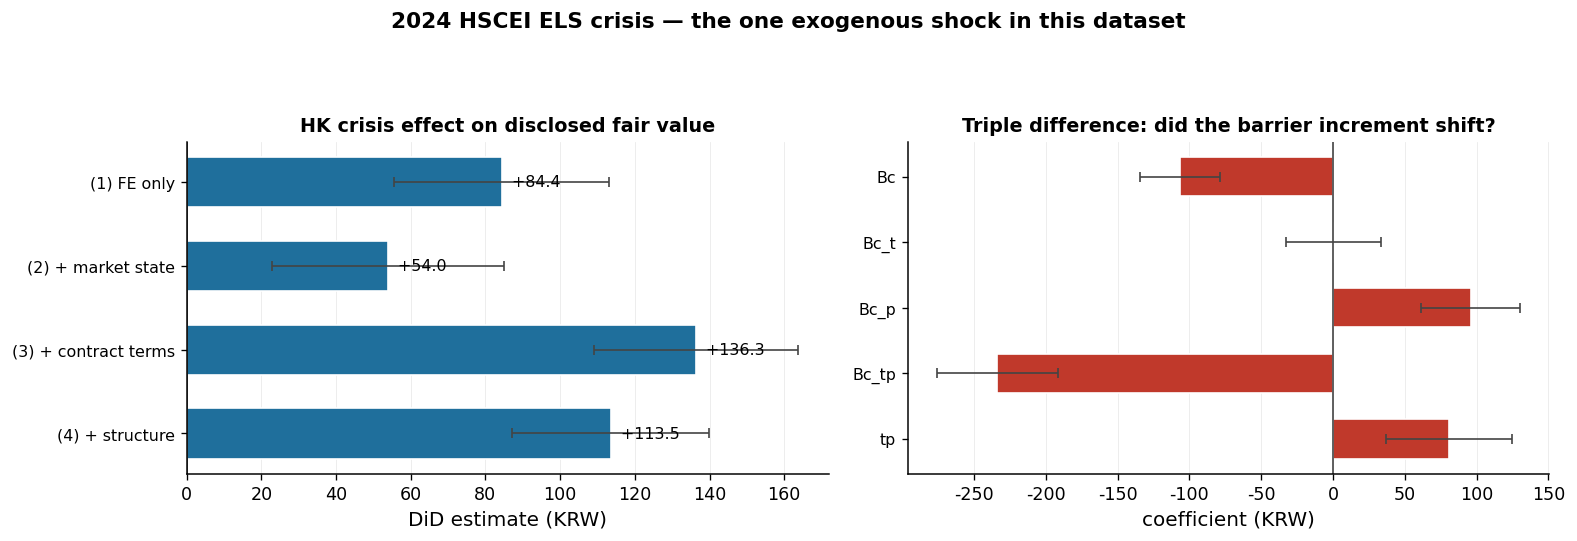

saved -> ci_did.png


In [8]:
# 2x2 DiD: 사양 4개 (통제 강화) + 삼중차분
SPECS = []


def did_spec(label, extra_cols, data=dd):
    d = data.dropna(subset=["y", "treat", "post"] + extra_cols).copy()
    # post 는 월 고정효과의 선형결합이라 넣으면 설계행렬이 특이해진다 -> 제외 (FE 가 흡수)
    base = pd.DataFrame({"treat": d.treat, "tp": d.treat*d.post}, index=d.index)
    FE_ = pd.concat([pd.get_dummies(d.ym.astype(str), prefix="m", dtype=float).iloc[:, 1:],
                     pd.get_dummies(d.issuer.astype(str), prefix="i", dtype=float).iloc[:, 1:]], axis=1)
    blocks = [base] + ([d[extra_cols].astype(float)] if extra_cols else []) + [FE_]
    X_ = pd.concat(blocks, axis=1)
    X_ = sm.add_constant(X_.astype(float))
    m = ols_cluster(d.y.values, X_.values, d.isu_ord.values)
    j = list(X_.columns).index("tp")
    cond = float(np.linalg.cond(X_.values.astype(float)))   # 설계행렬 조건수 (특이성 진단)
    SPECS.append({"spec": label, "n": len(d), "did": m.params[j], "se": m.bse[j],
                  "t": m.params[j]/m.bse[j], "cond": cond})


# 통제변수는 **월 안에서 실제로 변하는 것**만 넣는다. r / curve_level / recent_mktvol 은
# 발행일 단위 시장변수라 월 고정효과가 이미 흡수한다 — 넣으면 설계행렬이 특이해진다
# (실측: 월내 평균 sd 가 curve_level 0.0000, r 0.0001, recent_mktvol 0.0023).
# 월내 변동이 남는 시장변수는 바스켓에서 오는 sig_eff(0.0287) 와 rho(0.0575) 뿐이다.
MKT = ["sig_eff", "rho"]
did_spec("(1) FE only", [])
did_spec("(2) + market state", MKT)
did_spec("(3) + contract terms", MKT + ["B", "K", "Kfirst", "coupon", "nobs", "tenor"])
did_spec("(4) + structure", MKT + ["B", "K", "Kfirst", "coupon", "nobs", "tenor",
                                   "ki_yn", "is_lizard"])
DID = pd.DataFrame(SPECS)
DID.to_csv(fm.stat("ci_did_specs"), index=False)
print("=== 2x2 DiD (처리 x 사후) — 통제를 강화하며 ===")
print(DID.assign(ci=lambda x: (x.did-1.96*x.se).round(1).astype(str)+" ~ "+(x.did+1.96*x.se).round(1).astype(str))
      [["spec", "n", "did", "se", "t", "ci", "cond"]].round(2).to_string(index=False))
print("\n  (3)->(4) 에서 계수가 크게 줄면 그만큼이 구성효과(살아남은 상품의 조건이 달라진 것)다.")

# 삼중차분: 사태 이후 배리어 증분이 달라졌는가 (KI 상품만, 셀 FE 대신 월/발행사 FE)
ki = dd[dd.ki_yn.astype(int) == 1].dropna(subset=["B", "y"]).copy()
ki["Bc"] = (ki.B.astype(float) - ki.B.astype(float).mean()) / UNIT["B"][0]   # +5%p 단위
# post 주효과는 월 FE 가 흡수한다. 상호작용(Bc_p 등)은 월 안에서 변하므로 식별된다.
trip = pd.DataFrame({"treat": ki.treat, "tp": ki.treat*ki.post,
                     "Bc": ki.Bc, "Bc_t": ki.Bc*ki.treat, "Bc_p": ki.Bc*ki.post,
                     "Bc_tp": ki.Bc*ki.treat*ki.post}, index=ki.index)
FE3 = pd.concat([pd.get_dummies(ki.ym.astype(str), prefix="m", dtype=float).iloc[:, 1:],
                 pd.get_dummies(ki.issuer.astype(str), prefix="i", dtype=float).iloc[:, 1:]], axis=1)
X3 = sm.add_constant(pd.concat([trip, FE3], axis=1).astype(float))
m3 = ols_cluster(ki.y.values, X3.values, ki.isu_ord.values)
cols = list(X3.columns)
print("삼중차분 설계행렬 조건수 = %.2e   (1e10 이상이면 특이성 의심)"
      % np.linalg.cond(X3.values.astype(float)))
print(ki.groupby(["treat", "post"]).agg(n=("y", "size"), B_mean=("B", "mean")).round(3).to_string())
TRI = pd.DataFrame([{"coef": c, "est": m3.params[cols.index(c)], "se": m3.bse[cols.index(c)]}
                    for c in ["Bc", "Bc_t", "Bc_p", "Bc_tp", "tp"]])
TRI["t"] = TRI.est/TRI.se
TRI.to_csv(fm.stat("ci_did_triple"), index=False)
print(f"\n=== 삼중차분: 배리어 증분(+5%p)이 사태 이후 홍콩군에서 달라졌는가  (KI 상품 {len(ki):,}건) ===")
print(TRI.round(2).to_string(index=False))
print("  Bc_tp 가 삼중차분 계수 — 0 과 구별되지 않으면 '증분은 충격에도 변하지 않았다'.")

fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 4.6))
y = np.arange(len(DID))
ax[0].barh(y, DID.did, .6, xerr=1.96*DID.se, color=_plot._QUAL[0], edgecolor="white",
           error_kw=dict(ecolor="#444", lw=1.0, capsize=3))
for i, v in enumerate(DID.did):
    ax[0].text(v, i, f"  {v:+.1f}", va="center", fontsize=9.5)
ax[0].set_yticks(y); ax[0].set_yticklabels(DID.spec, fontsize=9.5); ax[0].invert_yaxis()
ax[0].axvline(0, color="#444", lw=1.0); ax[0].set_xlabel("DiD estimate (KRW)")
ax[0].set_title("HK crisis effect on disclosed fair value", fontsize=11.5)
ax[0].grid(axis="x", color="#dddddd", lw=.5, alpha=.6)

y2 = np.arange(len(TRI))
c = ["#c0392b" if abs(t) > 1.96 else "#bbbbbb" for t in TRI.t]
ax[1].barh(y2, TRI.est, .6, xerr=1.96*TRI.se, color=c, edgecolor="white",
           error_kw=dict(ecolor="#444", lw=1.0, capsize=3))
ax[1].set_yticks(y2); ax[1].set_yticklabels(TRI.coef, fontsize=9.5); ax[1].invert_yaxis()
ax[1].axvline(0, color="#444", lw=1.0); ax[1].set_xlabel("coefficient (KRW)")
ax[1].set_title("Triple difference: did the barrier increment shift?", fontsize=11.5)
ax[1].grid(axis="x", color="#dddddd", lw=.5, alpha=.6)
fig.suptitle("2024 HSCEI ELS crisis — the one exogenous shock in this dataset",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.91))
fig.savefig(fm.image("ci_did")); plt.show()
print("saved ->", fm.image("ci_did").name)

## 13-4. 종합 — 설계를 강화하면 증분은 어떻게 움직이는가

세 층을 한 장에 모은다. 읽는 법은 이렇다.

- **12번 FWL → 쌍둥이 A(다변량)** 으로 갈수록 신뢰구간이 좁아지고 값이 바뀌면, 12번 값에 교란이 남아 있었다는 뜻이다.
- **쌍둥이 A 다변량**이 이 데이터에서 얻을 수 있는 가장 강한 조건부 증분이다. 그래도 조건 동시선택
  내생성은 남으므로 "그리스"라고 부르지 않는다.
- **DiD 는 이 데이터에서 인과 근거를 주지 못했다.** 사건연구의 사전추세 결합검정이 기각되었고
  (사전기 평균 |계수| 가 DiD 추정치와 같은 자릿수), 사태 후 홍콩 편입 발행이 70% 급감해 구성효과까지
  겹친다. 2024-01 은 깨끗한 단절이 아니라 **2022년부터 진행되던 홍콩지수 하락의 한 지점**이었다는 뜻이다.
  계수는 표에 남기되 **인과효과로 인용하지 않는다.**

즉 이 노트북이 실제로 얻은 것은 **쌍둥이 within-cell 증분**이고, 그것도 인과가 아니라 "시장·발행사·시점·
다른 계약조건까지 고정한 조건부 증분" 이다. 그래도 12번의 FWL 부분증분보다 훨씬 강한 통제이며,
아래 요약이 보여주듯 값이 크게 달라진다.


=== 증분 (원/단위) ===
design  nb12 FWL  twin A multi  twin A uni
term                                      
B         -156.2         -24.1       -14.4
K           -7.4         -25.4        23.9
Kfirst    -106.2         -53.1       -96.9
coupon     -68.8         -76.7       -93.9
nobs        16.3           NaN         NaN

=== 95% CI 반폭 (좁을수록 정밀) ===
design  nb12 FWL  twin A multi  twin A uni
term                                      
B            5.0           1.8         1.0
K            2.3           6.7         3.6
Kfirst       3.4           7.7         4.5
coupon       3.6          10.6         8.3
nobs         2.4           NaN         NaN


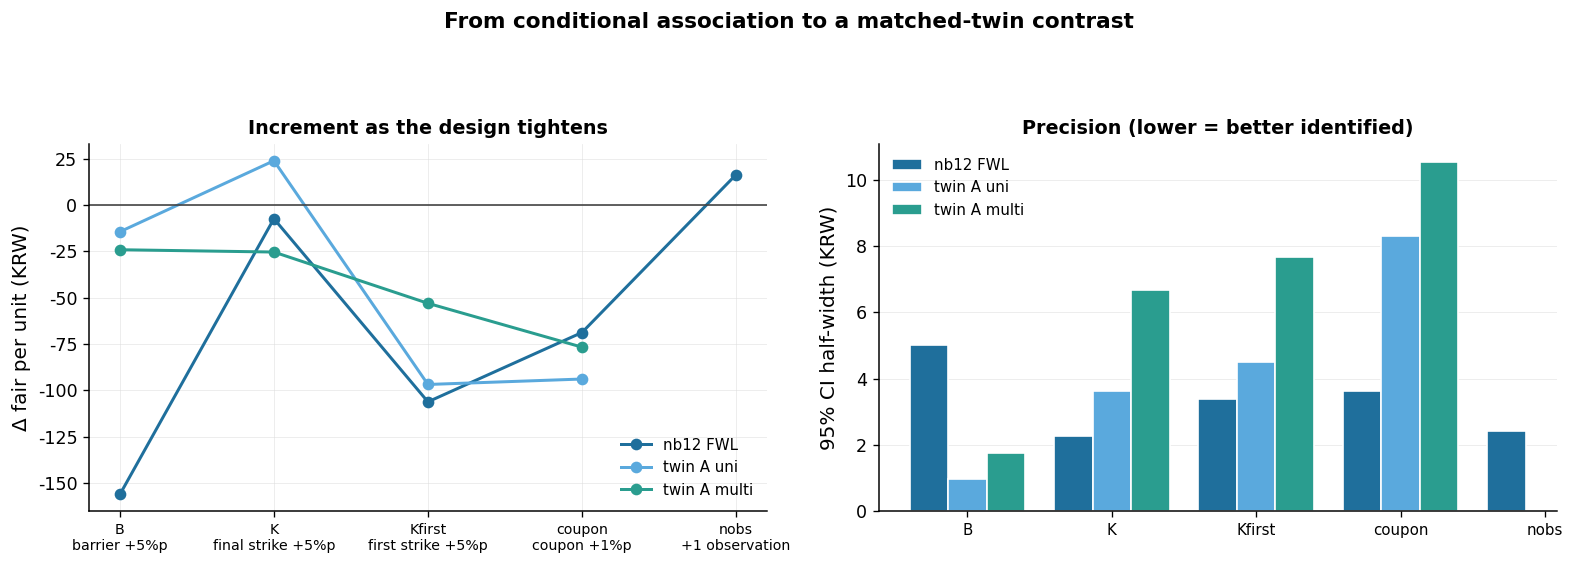

saved -> ci_summary.png | ci_summary.csv


In [9]:
# 종합: 설계 강화에 따른 증분 이동 + 신뢰구간 축소
rows = []
for t in PRIMARY:
    for lab, c, k in [("nb12 FWL", "12: FWL partial", "partial (nb12)"),
                      ("twin A uni", "A: issuer x date x basket x tenor x nobs", "within-uni"),
                      ("twin A multi", "A: issuer x date x basket x tenor x nobs", "within-multi")]:
        s = CMP[(CMP.cell == c) & (CMP.kind == k) & (CMP.term == t)]
        if len(s):
            rows.append({"term": t, "design": lab, "slope": float(s.slope.iloc[0]),
                         "ci_halfwidth": float(1.96*s.se.iloc[0])})
SUM = pd.DataFrame(rows)
SUM.to_csv(fm.stat("ci_summary"), index=False)
PV = SUM.pivot(index="term", columns="design", values="slope").reindex(PRIMARY)
CI = SUM.pivot(index="term", columns="design", values="ci_halfwidth").reindex(PRIMARY)
print("=== 증분 (원/단위) ===");  print(PV.round(1).to_string())
print("\n=== 95% CI 반폭 (좁을수록 정밀) ===");  print(CI.round(1).to_string())

fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 4.8))
DESIGNS = [d for d in ["nb12 FWL", "twin A uni", "twin A multi"] if d in PV.columns]
x = np.arange(len(PRIMARY))
for j, d_ in enumerate(DESIGNS):
    ax[0].plot(x, PV[d_].values, "o-", ms=6, lw=1.8, label=d_, color=_plot._QUAL[j])
ax[0].axhline(0, color="#444", lw=1.0); ax[0].set_xticks(x)
ax[0].set_xticklabels([f"{t}\n{UNIT[t][1]}" for t in PRIMARY], fontsize=8.5)
ax[0].set_ylabel("Δ fair per unit (KRW)"); ax[0].legend(fontsize=9)
ax[0].set_title("Increment as the design tightens", fontsize=11.5)
ax[0].grid(color="#dddddd", lw=.5, alpha=.6)

w = .8/len(DESIGNS)
for j, d_ in enumerate(DESIGNS):
    ax[1].bar(x + (j-(len(DESIGNS)-1)/2)*w, CI[d_].values, w, label=d_,
              color=_plot._QUAL[j], edgecolor="white")
ax[1].set_xticks(x); ax[1].set_xticklabels(PRIMARY, fontsize=9)
ax[1].set_ylabel("95% CI half-width (KRW)"); ax[1].legend(fontsize=9)
ax[1].set_title("Precision (lower = better identified)", fontsize=11.5)
ax[1].grid(axis="y", color="#dddddd", lw=.5, alpha=.6)
fig.suptitle("From conditional association to a matched-twin contrast",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.91))
fig.savefig(fm.image("ci_summary")); plt.show()
print("saved ->", fm.image("ci_summary").name, "|", fm.stat("ci_summary").name)

## 13-5. 정확일치 쌍 — 교란을 회귀가 아니라 **설계**로 제거

13-1 은 다른 계약조건을 **회귀로** 통제했다. 그건 선형성을 가정한다. 여기서는 가정 없이
**같은 발행사가 같은 날 같은 기초자산 바스켓으로 낸 상품 중, 나머지 조건이 전부 똑같고
딱 한 항목만 다른 쌍**만 골라 그 쌍 안에서 차분한다.

$$\Delta \text{fair}_{ij} \;/\; \Delta \text{term}_{ij}, \qquad
\text{단 } \text{term}' _i = \text{term}'_j \ \ \forall\, \text{term}' \neq \text{term}$$

이 쌍 안에서는 시장상태·발행사·발행시점·다른 계약조건이 **모두 문자 그대로 동일**하다. 남는 것은
그 한 항목의 차이뿐이므로, 이 데이터에서 얻을 수 있는 가장 깨끗한 대조다.

**이 설계가 드러내는 진짜 제약이 있다.** 어떤 조건은 발행사가 **혼자 움직이지 않는다.**
그런 항목은 쌍이 만들어지지 않고, 따라서 이 데이터로는 그 효과를 분리할 수 없다.
아래에서 항목별로 (1) 얼마나 많은 단독변동 쌍이 존재하는지, (2) 그 항목이 달라질 때 무엇이
함께 달라지는지를 먼저 보고, 쌍이 충분한 항목에 대해서만 증분을 보고한다.


In [10]:
# 정확일치 쌍 열거 (같은 발행사·발행일·바스켓, 한 항목만 상이)
from itertools import combinations

TT = ["B", "K", "Kfirst", "coupon", "nobs", "tenor"]
UNIT2 = {"B": (.05, "barrier +5%p"), "K": (.05, "final strike +5%p"),
         "Kfirst": (.05, "first strike +5%p"), "coupon": (.01, "coupon +1%p"),
         "nobs": (1., "+1 observation"), "tenor": (.5, "tenor +0.5y")}
MIN_PAIRS = 50          # 이보다 적으면 '식별 불가' 로 보고

dpair = df.dropna(subset=TT + ["fair"]).copy()
for t in TT:
    dpair[t + "_r"] = dpair[t].round(4)
RC = [t + "_r" for t in TT]

pairs, cofreq, tot_diff = [], {t: np.zeros(len(TT)) for t in TT}, {t: 0 for t in TT}
for _, g in dpair.groupby(["issuer", "isu_ord", "udl_key"], sort=False):
    if len(g) < 2 or len(g) > 40:
        continue
    V = g[RC].values; idx = g.index.values
    for a, b in combinations(range(len(g)), 2):
        diff = V[a] != V[b]
        k = int(diff.sum())
        if k == 0:
            continue
        for p, t in enumerate(TT):                      # 동반변동 빈도
            if diff[p]:
                cofreq[t] += diff; tot_diff[t] += 1
        if k == 1:                                      # 단독변동 쌍
            p = int(np.argmax(diff))
            pairs.append({"term": TT[p], "i": idx[a], "j": idx[b],
                          "dx": V[b][p] - V[a][p],
                          "dy": (dpair.fair.loc[idx[b]] - dpair.fair.loc[idx[a]]) * FACE,
                          "day": dpair.isu_ord.loc[idx[a]]})
PR = pd.DataFrame(pairs)
PR.to_csv(fm.stat("ci_exact_pairs"), index=False)

print("=== 단독변동 쌍 수 (한 항목만 다른 쌍) ===")
for t in TT:
    n = int((PR.term == t).sum())
    flag = "" if n >= MIN_PAIRS else "   <- 식별 불가 (발행사가 이 항목을 단독으로 움직이지 않는다)"
    print(f"  {t:8s} {n:6,d}{flag}")

print("\n=== 그 항목이 달라질 때 함께 달라지는 항목 (%) ===")
CO = pd.DataFrame({t: cofreq[t] / max(tot_diff[t], 1) * 100 for t in TT}, index=TT).T
CO.index.name = "이 항목이 다를 때"
print(CO.round(1).to_string())


def pair_slope(t, reps=600, seed=0):
    """쌍 내 차분 증분 + 발행일 클러스터 부트스트랩 CI."""
    s = PR[PR.term == t]
    dx = s.dx.values / UNIT2[t][0]; dy = s.dy.values; day = s.day.values
    ok = np.abs(dx) > 1e-9
    dx, dy, day = dx[ok], dy[ok], day[ok]
    b = float(np.sum(dy*dx) / np.sum(dx**2))
    ud = np.unique(day); rng = np.random.default_rng(seed); bs = []
    for _ in range(reps):
        pick = rng.choice(ud, len(ud), replace=True)
        m = np.concatenate([np.flatnonzero(day == u) for u in pick])
        bs.append(np.sum(dy[m]*dx[m]) / np.sum(dx[m]**2))
    return {"term": t, "n_pair": len(dx), "slope": b,
            "lo": float(np.percentile(bs, 2.5)), "hi": float(np.percentile(bs, 97.5))}


EX = pd.DataFrame([pair_slope(t) for t in TT if (PR.term == t).sum() >= MIN_PAIRS])
EX.to_csv(fm.stat("ci_exact_slopes"), index=False)
print("\n=== 정확일치 쌍 증분 (원/단위, 발행가 10,000) ===")
print(EX.assign(unit=[UNIT2[t][1] for t in EX.term],
                ci=lambda x: "[" + x.lo.round(1).astype(str) + ", " + x.hi.round(1).astype(str) + "]")
      [["term", "unit", "n_pair", "slope", "ci"]].round(1).to_string(index=False))
print("\n  tenor 는 쌍이 있어도 차이가 며칠 수준(일수 계산 차이)이라 만기 효과로 해석하면 안 된다.")

=== 단독변동 쌍 수 (한 항목만 다른 쌍) ===
  B            11   <- 식별 불가 (발행사가 이 항목을 단독으로 움직이지 않는다)
  K            55
  Kfirst      246
  coupon    4,710
  nobs         21   <- 식별 불가 (발행사가 이 항목을 단독으로 움직이지 않는다)
  tenor       265

=== 그 항목이 달라질 때 함께 달라지는 항목 (%) ===
                B      K  Kfirst  coupon   nobs  tenor
이 항목이 다를 때                                            
B           100.0   84.0    68.9    97.0   17.0   41.4
K            69.6  100.0    70.1    96.9   15.6   45.6
Kfirst       41.3   50.8   100.0    97.2   16.0   35.8
coupon       40.8   49.2    68.2   100.0   15.5   35.6
nobs         44.7   49.6    70.3    97.2  100.0   39.5
tenor        47.1   62.7    67.9    96.2   17.1  100.0



=== 정확일치 쌍 증분 (원/단위, 발행가 10,000) ===
  term              unit  n_pair   slope                ci
     K final strike +5%p      55   -41.2    [-63.5, -17.7]
Kfirst first strike +5%p     246   -54.4     [-93.5, -8.4]
coupon       coupon +1%p    4710   -80.8    [-91.8, -70.2]
 tenor       tenor +0.5y     265 -1098.0 [-2252.9, -303.0]

  tenor 는 쌍이 있어도 차이가 며칠 수준(일수 계산 차이)이라 만기 효과로 해석하면 안 된다.


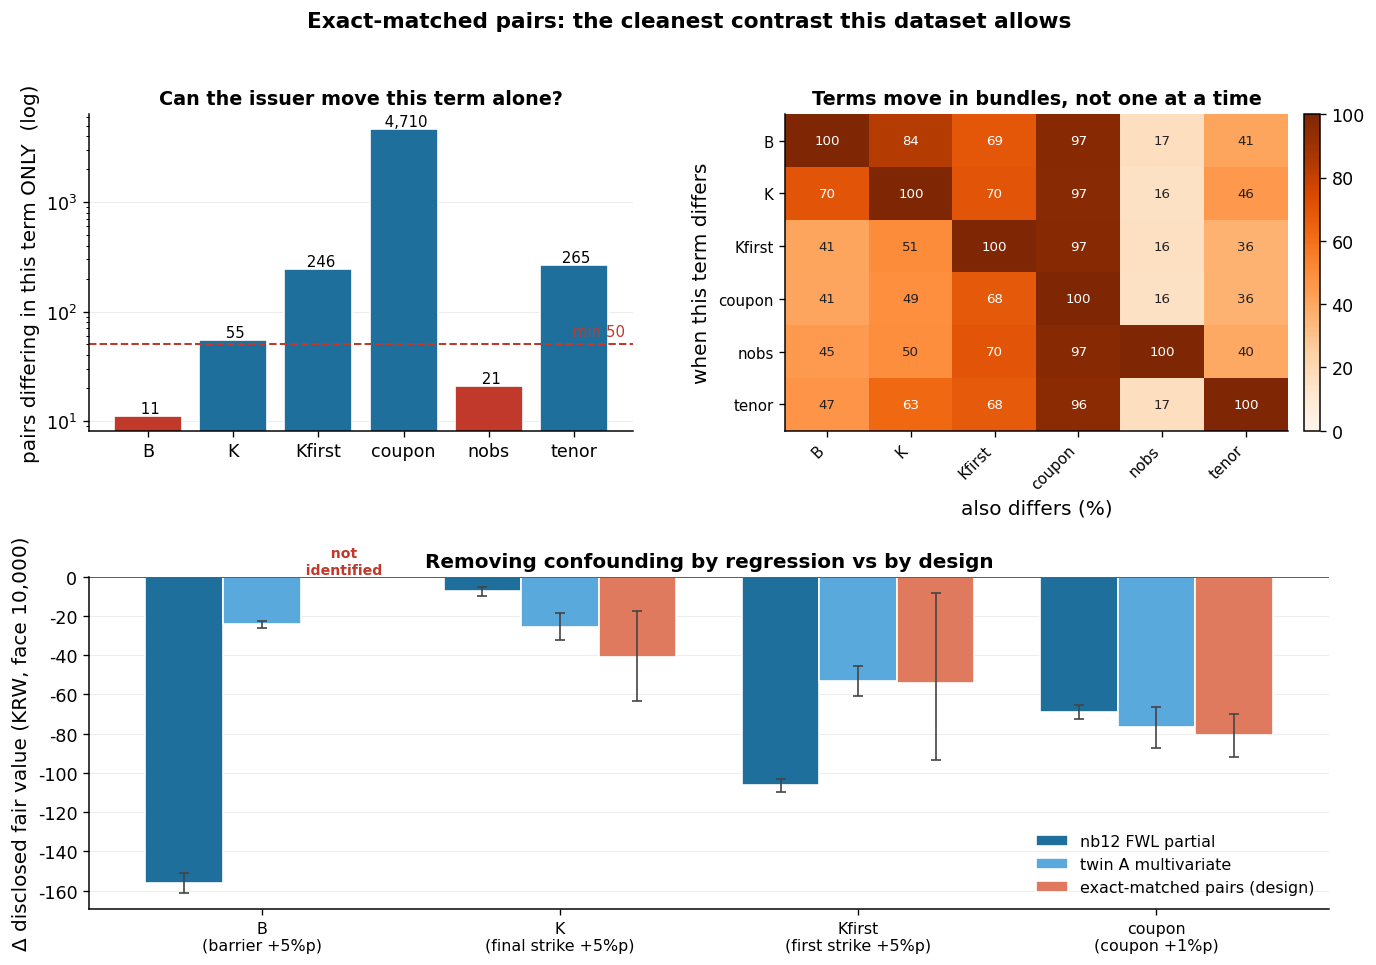

saved -> ci_exact_pairs.png | ci_exact_slopes.csv


In [11]:
# 그림: 단독변동 가능성 · 동반변동 구조 · 설계별 증분 비교
fig = plt.figure(figsize=(_plot.SLIDE_W, 8.6))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.05], hspace=.45, wspace=.28)

# (1) 단독변동 쌍 수
a0 = fig.add_subplot(gs[0, 0])
n_solo = [int((PR.term == t).sum()) for t in TT]
c = [_plot._QUAL[0] if n >= MIN_PAIRS else "#c0392b" for n in n_solo]
a0.bar(TT, np.maximum(n_solo, .5), color=c, edgecolor="white")
a0.set_yscale("log"); a0.axhline(MIN_PAIRS, color="#c0392b", lw=1.2, ls="--")
a0.text(len(TT)-.4, MIN_PAIRS*1.2, f" min {MIN_PAIRS}", color="#c0392b", fontsize=9, ha="right")
for i, n in enumerate(n_solo):
    a0.text(i, max(n, .5), f" {n:,}", ha="center", va="bottom", fontsize=9)
a0.set_ylabel("pairs differing in this term ONLY  (log)")
a0.set_title("Can the issuer move this term alone?", fontsize=11.5)
a0.grid(axis="y", color="#dddddd", lw=.5, alpha=.6)

# (2) 동반변동 히트맵
a1 = fig.add_subplot(gs[0, 1])
im = a1.imshow(CO.values, cmap="Oranges", vmin=0, vmax=100, aspect="auto")
a1.set_xticks(range(len(TT))); a1.set_xticklabels(TT, rotation=45, ha="right", fontsize=9)
a1.set_yticks(range(len(TT))); a1.set_yticklabels(TT, fontsize=9)
for i in range(len(TT)):
    for j in range(len(TT)):
        v = CO.values[i, j]
        a1.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8,
                color="white" if v > 60 else "#222")
a1.set_xlabel("also differs (%)"); a1.set_ylabel("when this term differs")
a1.set_title("Terms move in bundles, not one at a time", fontsize=11.5)
fig.colorbar(im, ax=a1, fraction=.046, pad=.03)

# (3) 설계별 증분 비교
a2 = fig.add_subplot(gs[1, :])
try:
    W = pd.read_csv(fm.stat("ci_within_slopes"))
    TW = W[(W.cell.str.startswith("A")) & (W.kind == "within-multi")].set_index("term")
except FileNotFoundError:
    TW = pd.DataFrame()
try:
    N12 = pd.read_csv(fm.stat("ct_slope_overall"))
    N12 = N12[N12.kind == "partial"].set_index("term")
except FileNotFoundError:
    N12 = pd.DataFrame()

SHOW = [t for t in ["B", "K", "Kfirst", "coupon"] if t in set(TT)]
x = np.arange(len(SHOW)); w = .26
series = [("nb12 FWL partial", N12, "slope", "se"), ("twin A multivariate", TW, "slope", "se")]
for j, (lab, D_, sc, ec) in enumerate(series):
    if not len(D_):
        continue
    v = [D_[sc].get(t, np.nan) for t in SHOW]
    e = [1.96*D_[ec].get(t, np.nan) for t in SHOW]
    a2.bar(x + (j-1)*w, v, w, yerr=e, label=lab, color=_plot._QUAL[j], edgecolor="white",
           error_kw=dict(ecolor="#444", lw=1.0, capsize=3))
EXi = EX.set_index("term")
v = [EXi.slope.get(t, np.nan) for t in SHOW]
lo = [EXi.slope.get(t, np.nan) - EXi.lo.get(t, np.nan) for t in SHOW]
hi = [EXi.hi.get(t, np.nan) - EXi.slope.get(t, np.nan) for t in SHOW]
a2.bar(x + w, v, w, yerr=[lo, hi], label="exact-matched pairs (design)",
       color=_plot._QUAL[3], edgecolor="white", error_kw=dict(ecolor="#444", lw=1.0, capsize=3))
for i, t in enumerate(SHOW):
    if t not in EXi.index:
        a2.text(i + w, 0, "  not\n  identified", ha="center", va="bottom",
                fontsize=8.5, color="#c0392b", fontweight="bold")
a2.set_xticks(x); a2.set_xticklabels([f"{t}\n({UNIT2[t][1]})" for t in SHOW], fontsize=9.5)
a2.axhline(0, color="#444", lw=1.0)
a2.set_ylabel("Δ disclosed fair value (KRW, face 10,000)")
a2.set_title("Removing confounding by regression vs by design", fontsize=12)
a2.legend(fontsize=9.5); a2.grid(axis="y", color="#dddddd", lw=.5, alpha=.6)

fig.suptitle("Exact-matched pairs: the cleanest contrast this dataset allows",
             fontsize=13, fontweight="bold")
fig.savefig(fm.image("ci_exact_pairs")); plt.show()
print("saved ->", fm.image("ci_exact_pairs").name, "|", fm.stat("ci_exact_slopes").name)

### 13-5 판정

- **쿠폰**은 단독변동 쌍이 수천 개라 **설계로 식별된다.** 회귀 기반 추정과 값이 거의 같으면
  "선형 통제가 만들어낸 결과가 아니다" 라는 강한 증거다.
- **배리어**는 단독변동 쌍이 사실상 없다. 발행사는 배리어를 움직일 때 쿠폰을 거의 항상 같이 움직인다.
  따라서 **이 데이터로 배리어의 독립 효과는 식별되지 않는다** — 13-1 의 배리어 값(−24원)은 회귀의
  선형 외삽에 의존한 값이며, 실제로는 거의 존재하지 않는 반사실을 가리킨다.
- 배리어 효과를 알고 싶다면 관측 데이터로는 부족하고, 조건을 하나만 흔들어 재가격하는
  **가격모형 기반 반사실**(MC/모델)이 필요하다. 그건 이 노트북 밖의 도구다.
